Total mask pixels: 41199.0


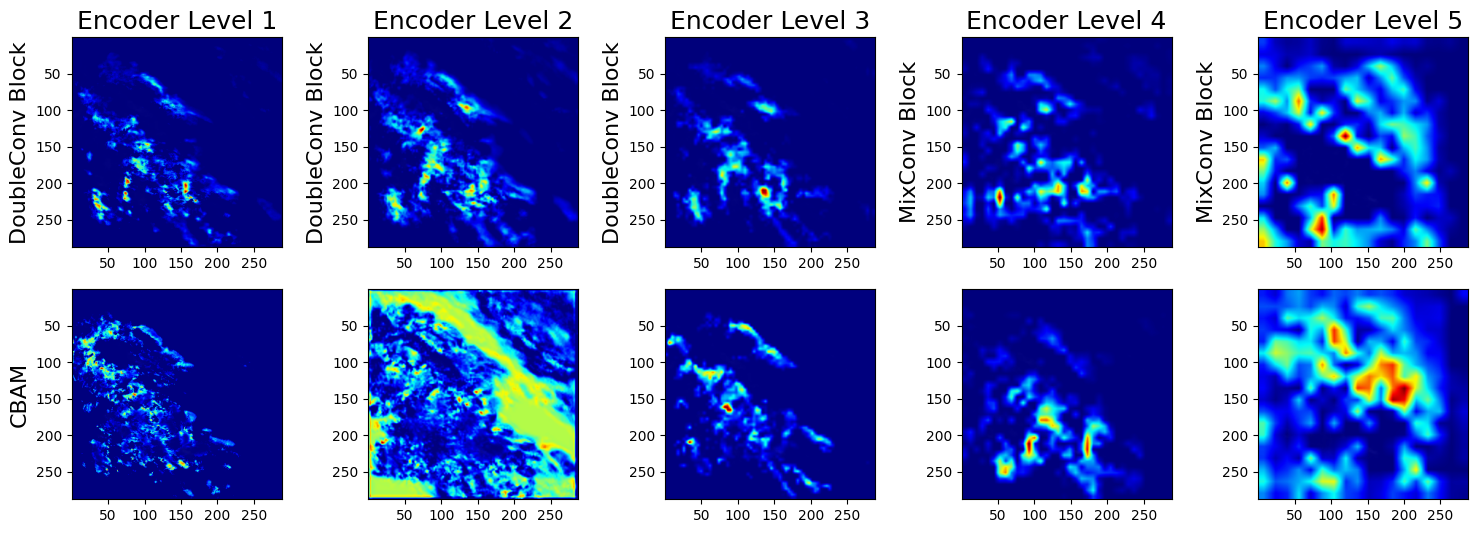

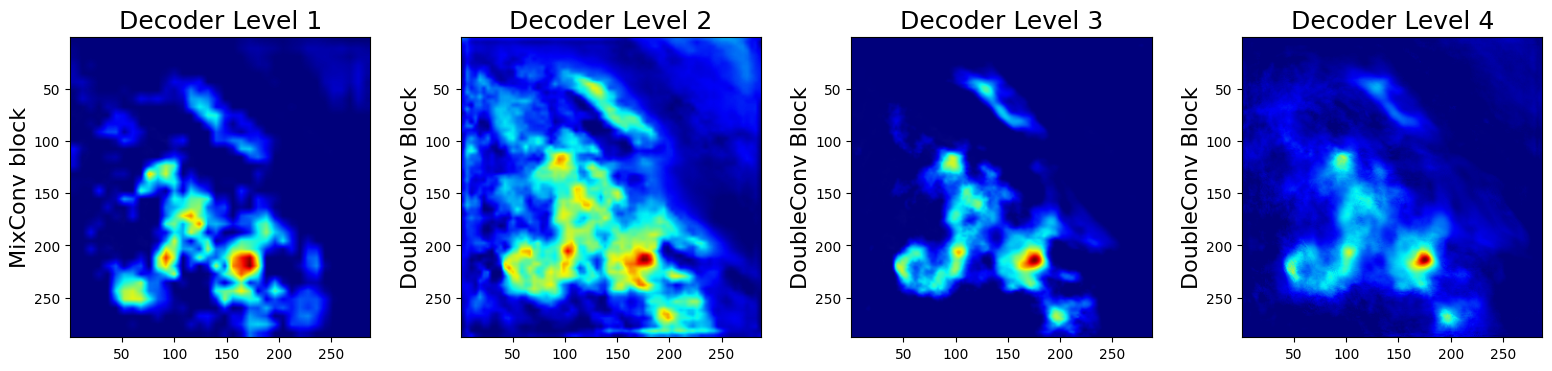

In [1]:
from torch.utils.data import DataLoader
import numpy as np
import os
import torch
from utils import dataset_precip
from tqdm import tqdm
from models import SmaAT_UNet_VQ_lightning
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM
from argparse import Namespace

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')


class SemanticSegmentationTarget:
    def __init__(self, category, mask, device):
        self.category = category
        self.mask = torch.from_numpy(mask)
        if device == 'cuda':
            self.mask = self.mask.cuda()

    def __call__(self, model_output):
        return (model_output[self.category, :, :] * self.mask).sum()


def load_model(model_cls, model_folder, device, model_type="partialmixconv"):
    ckpts = [fn for fn in os.listdir(model_folder) if fn.endswith(".ckpt")]
    if not ckpts:
        raise FileNotFoundError(f"No .ckpt found in {model_folder!r}")
    ckpt_file = sorted(ckpts)[-1]
    ckpt_path = os.path.join(model_folder, ckpt_file)
    checkpoint = torch.load(ckpt_path, map_location=device)
    hparams = checkpoint.get("hyper_parameters", {})
    if "model_type" not in hparams:
        hparams["model_type"] = model_type
    model = model_cls(Namespace(**hparams))
    state_dict = checkpoint.get("state_dict", checkpoint)
    new_state_dict = {
        key[len("model."):] if key.startswith("model.") else key: val
        for key, val in state_dict.items()
    }
    model.load_state_dict(new_state_dict)
    model.eval()
    model.to(torch.device(device))
    return model


def get_segmentation_data(in_channels):
    ds = dataset_precip.precipitation_maps_oversampled_h5(
        in_file=data_file,
        num_input_images=in_channels,
        num_output_images=6,
        train=False
    )
    return DataLoader(ds, batch_size=1, shuffle=False,
                      num_workers=0, pin_memory=True)


def run_cam(model, target_layers, device, in_channels, image_index=0):
    # Get dataset directly instead of using DataLoader
    ds = dataset_precip.precipitation_maps_oversampled_h5(
        in_file=data_file,
        num_input_images=in_channels,
        num_output_images=6,
        train=False
    )
    
    # Select specific image
    x, _ = ds[image_index]
    x = torch.tensor(x).unsqueeze(0)  # Add batch dimension
    x_ticks = [50, 100, 150, 200, 250]

    x = x.to(torch.device(device))
    logits, _, _ = model(x)

    # build mask for Grad-CAM
    mask = np.digitize(
        (logits[0, 0] * 47.83 * 12).detach().cpu().numpy(),
        np.array([0.5]), right=True
    ).astype(np.float32)

    print("Total mask pixels:", mask.sum())

    # base image
    img = torch.stack([x[0, 0]] * 3, dim=2).cpu().numpy()
    targets = [SemanticSegmentationTarget(0, mask, device)]

    # compute CAMs
    cams_all = []
    for layer in target_layers:
        with GradCAM(model=model, target_layers=layer) as cam:
            gcam = cam(input_tensor=x, targets=targets)[0]
            cams_all.append(show_cam_on_image(img, gcam, use_rgb=True))

    # ─── OPTION 1 PATCH: split into encoder (first 10) and decoder (next 4) ───
    enc_imgs = cams_all[:10]    # encoder levels 1–10
    dec_imgs = cams_all[10:14]  # decoder levels 1–4

    # reset to default subplot spacing
    mpl.rcParams.update(mpl.rcParamsDefault)

    # ─── ENCODER: 2 rows × 5 columns ────────────────────────────────────
    fig, axes = plt.subplots(2, 5, figsize=(18.5, 6))
    idx = 0
    for row in range(2):
        for col in range(5):
            ax = axes[row, col]
            ax.imshow(enc_imgs[idx], extent=[0, 288, 288, 0])
            if row == 0:
                # column titles
                ax.set_title(f"Encoder Level {col+1}", fontsize=18)
                # block label per column
                if col < 3:
                    ax.set_ylabel("DoubleConv Block", fontsize=16)
                else:
                    ax.set_ylabel("MixConv Block", fontsize=16)
            else:
                # CBAM row: label only first column
                if col == 0:
                    ax.set_ylabel("CBAM", fontsize=16)
            ax.set_xticks(x_ticks)
            ax.set_yticks(x_ticks)
            idx += 1

    # ─── DECODER: 1 row × 4 columns ────────────────────────────────────
    decoder_blocks = [
        'MixConv block',
        'DoubleConv Block',
        'DoubleConv Block',
        'DoubleConv Block'
    ]
    fig2, axes2 = plt.subplots(1, 4, figsize=(19, 5))
    fig2.subplots_adjust(wspace=0.3)
    for col in range(4):
        ax = axes2[col]
        ax.imshow(dec_imgs[col], extent=[0, 288, 288, 0])
        ax.set_title(f"Decoder Level {col+1}", fontsize=18)
        ax.set_ylabel(decoder_blocks[col],
                      fontsize=16,
                      rotation=90,
                      labelpad=10,
                      va='center')
        ax.set_xticks(x_ticks)
        ax.set_yticks(x_ticks)

    plt.show()
    #break

if __name__ == '__main__':
    # hyperparameters (only dataset path used below)
    hparams = {
        'n_channels': 12,
        'dataset_folder': "data/precipitation/"
                          "train_test_2016-2019_input-length_12_"
                          "img-ahead_6_rain-threshold_50.h5"
    }

    model_folder = "checkpoints/comparison"
    data_file = os.path.join(hparams['dataset_folder'])
    device = 'cpu'

    model = load_model(
        SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ,
        model_folder,
        device
    )

    target_layers = [
        [model.inc.double_conv],
        [model.down1.maxpool_conv[1].double_conv],
        [model.down2.maxpool_conv[1].double_conv],
        [model.down3.maxpool_conv[1].mix1],
        [model.down4.maxpool_conv[1].mix1],
        [model.cbam1],     
        [model.cbam2],    
        [model.cbam3],     
        [model.cbam4],       
        [model.cbam5],
        [model.up1.conv.mix1],
        [model.up2.conv.double_conv],
        [model.up3.conv.double_conv],
        [model.up4.conv.double_conv],
    ]

    # 215, 821, 826, 1276 is good
    image_index = 1276
    run_cam(model, target_layers, device, hparams['n_channels'], image_index)


Total mask pixels: 41199.0


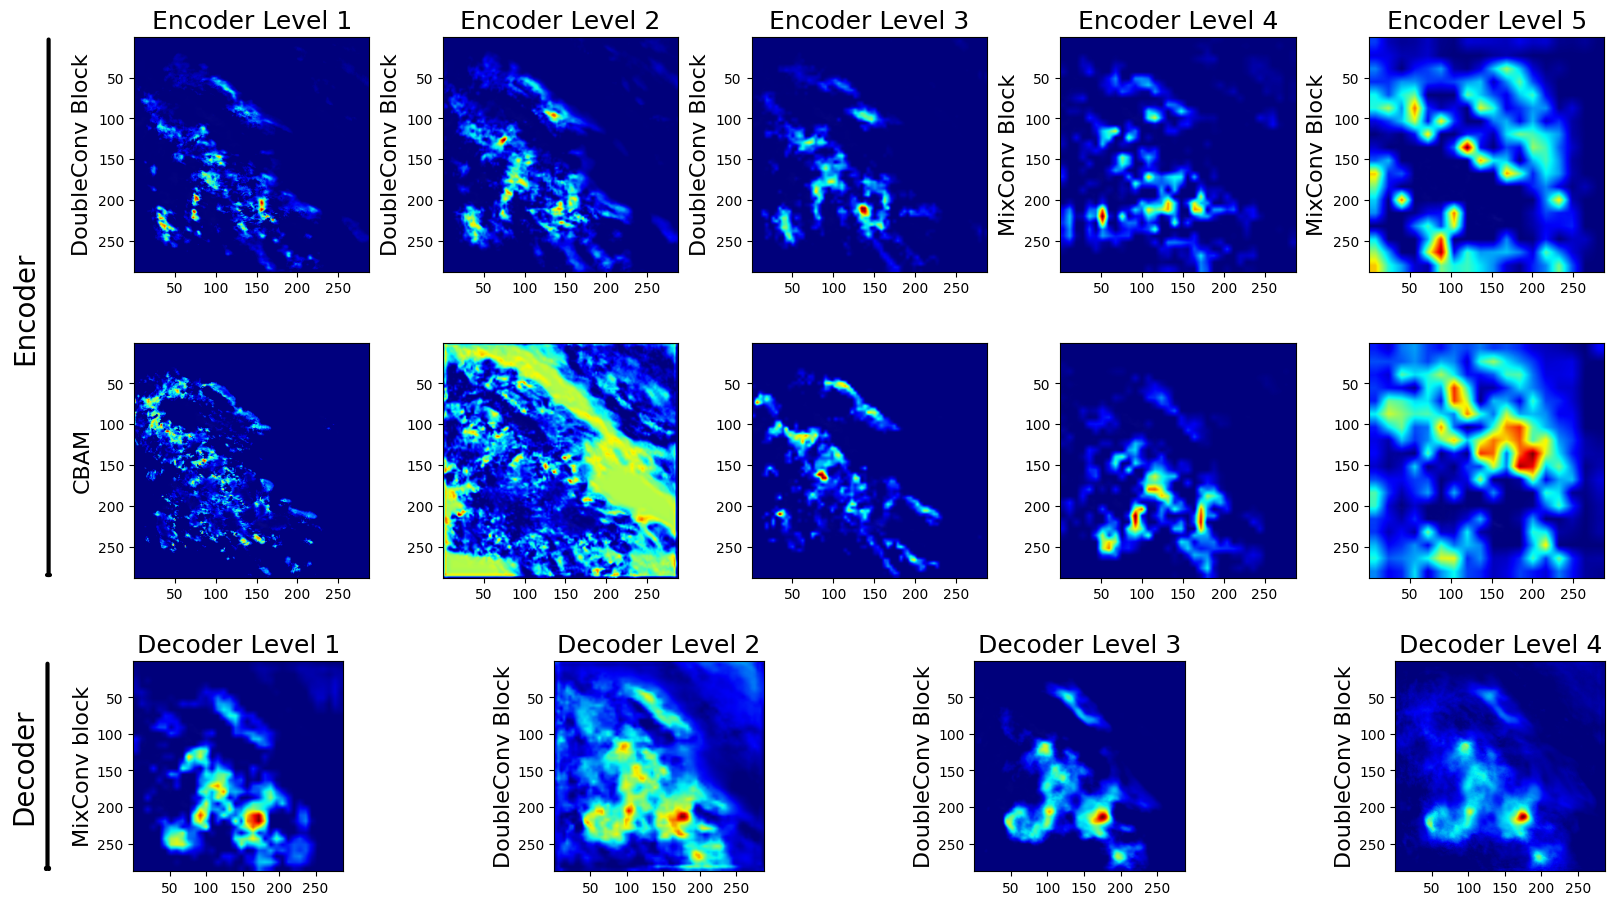

In [23]:
from torch.utils.data import DataLoader
import numpy as np
import os
import torch
from utils import dataset_precip
from tqdm import tqdm
from models import SmaAT_UNet_VQ_lightning
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from matplotlib.patches import FancyArrowPatch
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam import GradCAM
from argparse import Namespace

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')


class SemanticSegmentationTarget:
    def __init__(self, category, mask, device):
        self.category = category
        self.mask = torch.from_numpy(mask)
        if device == 'cuda':
            self.mask = self.mask.cuda()

    def __call__(self, model_output):
        return (model_output[self.category, :, :] * self.mask).sum()


def load_model(model_cls, model_folder, device, model_type="partialmixconv"):
    ckpts = [fn for fn in os.listdir(model_folder) if fn.endswith(".ckpt")]
    if not ckpts:
        raise FileNotFoundError(f"No .ckpt found in {model_folder!r}")
    ckpt_file = sorted(ckpts)[-1]
    ckpt_path = os.path.join(model_folder, ckpt_file)
    checkpoint = torch.load(ckpt_path, map_location=device)
    hparams = checkpoint.get("hyper_parameters", {})
    if "model_type" not in hparams:
        hparams["model_type"] = model_type
    model = model_cls(Namespace(**hparams))
    state_dict = checkpoint.get("state_dict", checkpoint)
    new_state_dict = {
        key[len("model."):] if key.startswith("model.") else key: val
        for key, val in state_dict.items()
    }
    model.load_state_dict(new_state_dict)
    model.eval()
    model.to(torch.device(device))
    return model


def get_segmentation_data(in_channels):
    ds = dataset_precip.precipitation_maps_oversampled_h5(
        in_file=data_file,
        num_input_images=in_channels,
        num_output_images=6,
        train=False
    )
    return DataLoader(ds, batch_size=1, shuffle=False,
                      num_workers=0, pin_memory=True)


def run_cam(model, target_layers, device, in_channels, image_index=0):
    # Get dataset directly instead of using DataLoader
    ds = dataset_precip.precipitation_maps_oversampled_h5(
        in_file=data_file,
        num_input_images=in_channels,
        num_output_images=6,
        train=False
    )
    
    # Select specific image
    x, _ = ds[image_index]
    x = torch.tensor(x).unsqueeze(0)  # Add batch dimension
    x_ticks = [50, 100, 150, 200, 250]

    x = x.to(torch.device(device))
    logits, _, _ = model(x)

    # build mask for Grad-CAM
    mask = np.digitize(
        (logits[0, 0] * 47.83 * 12).detach().cpu().numpy(),
        np.array([0.5]), right=True
    ).astype(np.float32)

    print("Total mask pixels:", mask.sum())

    # base image
    img = torch.stack([x[0, 0]] * 3, dim=2).cpu().numpy()
    targets = [SemanticSegmentationTarget(0, mask, device)]

    # compute CAMs
    cams_all = []
    for layer in target_layers:
        with GradCAM(model=model, target_layers=layer) as cam:
            gcam = cam(input_tensor=x, targets=targets)[0]
            cams_all.append(show_cam_on_image(img, gcam, use_rgb=True))

    # ─── OPTION 1 PATCH: split into encoder (first 10) and decoder (next 4) ───
    enc_imgs = cams_all[:10]    # encoder levels 1–10
    dec_imgs = cams_all[10:14]  # decoder levels 1–4

    # reset to default subplot spacing
    mpl.rcParams.update(mpl.rcParamsDefault)

    # ─── COMBINED FIGURE ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(19, 11))

    # outer grid: 3 rows × 5 cols
    outer = fig.add_gridspec(3, 5,
                             height_ratios=[6, 6, 6],
                             hspace=0.3, wspace=0.3)

    # ─── ENCODER: 2 rows × 5 columns ────────────────────────────────────
    axes = np.empty((2, 5), dtype=object)
    idx = 0
    for row in range(2):
        for col in range(5):
            ax = fig.add_subplot(outer[row, col])
            axes[row, col] = ax
            ax.imshow(enc_imgs[idx], extent=[0, 288, 288, 0])
            if row == 0:
                # column titles
                ax.set_title(f"Encoder Level {col+1}", fontsize=18)
                # block label per column
                if col < 3:
                    ax.set_ylabel("DoubleConv Block", fontsize=16)
                else:
                    ax.set_ylabel("MixConv Block", fontsize=16)
            else:
                # CBAM row: label only first column
                if col == 0:
                    ax.set_ylabel("CBAM", fontsize=16)
            ax.set_xticks(x_ticks)
            ax.set_yticks(x_ticks)
            idx += 1

    # ─── DECODER: 1 row × 4 columns (evenly spanning full width) ───────────
    sub_gs = outer[2, :].subgridspec(1, 4, wspace=1)
    axes2 = []
    decoder_blocks = [
        'MixConv block',
        'DoubleConv Block',
        'DoubleConv Block',
        'DoubleConv Block'
    ]
    for col in range(4):
        ax = fig.add_subplot(sub_gs[0, col])
        axes2.append(ax)
        ax.imshow(dec_imgs[col], extent=[0, 288, 288, 0])
        ax.set_title(f"Decoder Level {col+1}", fontsize=18)
        ax.set_ylabel(decoder_blocks[col],
                      fontsize=16,
                      rotation=90,
                      labelpad=10,
                      va='center')
        ax.set_xticks(x_ticks)
        ax.set_yticks(x_ticks)
    axes2 = np.array(axes2)

    # ─── BRACES AND LABELS ─────────────────────────────────────────────────

    # Encoder brace on the left
    first_enc = axes[0, 0]
    last_enc  = axes[1, 0]
    x0_enc    = first_enc.get_position().x0
    y1_enc    = first_enc.get_position().y1
    y0_enc    = last_enc.get_position().y0

    brace_enc = FancyArrowPatch(
        (x0_enc - 0.045, y1_enc),
        (x0_enc - 0.045, y0_enc),
        transform=fig.transFigure,
        arrowstyle='-[', linewidth=3, clip_on=False
    )

    fig.add_artist(brace_enc)
    fig.text(
        x0_enc - 0.05,
        (y1_enc + y0_enc) / 2,
        'Encoder',
        ha='right',
        va='center',
        rotation='vertical',
        fontsize=20
    )

    # Decoder brace on the left
    first_dec = axes2[0]
    x0_dec    = first_dec.get_position().x0
    y1_dec    = first_dec.get_position().y1
    y0_dec    = first_dec.get_position().y0

    brace_dec = FancyArrowPatch(
        (x0_dec - 0.045, y1_dec),
        (x0_dec - 0.045, y0_dec),
        transform=fig.transFigure,
        arrowstyle='-[', linewidth=3, clip_on=False
    )

    fig.add_artist(brace_dec)
    fig.text(
        x0_dec - 0.05,
        (y1_dec + y0_dec) / 2,
        'Decoder',
        ha='right',
        va='center',
        rotation='vertical',
        fontsize=20
    )

    plt.show()


if __name__ == '__main__':
    # hyperparameters (only dataset path used below)
    hparams = {
        'n_channels': 12,
        'dataset_folder': "data/precipitation/"
                          "train_test_2016-2019_input-length_12_"
                          "img-ahead_6_rain-threshold_50.h5"
    }

    model_folder = "checkpoints/comparison"
    data_file = os.path.join(hparams['dataset_folder'])
    device = 'cpu'

    model = load_model(
        SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ,
        model_folder,
        device
    )

    target_layers = [
        [model.inc.double_conv],
        [model.down1.maxpool_conv[1].double_conv],
        [model.down2.maxpool_conv[1].double_conv],
        [model.down3.maxpool_conv[1].mix1],
        [model.down4.maxpool_conv[1].mix1],
        [model.cbam1],
        [model.cbam2],
        [model.cbam3],
        [model.cbam4],
        [model.cbam5],
        [model.up1.conv.mix1],
        [model.up2.conv.double_conv],
        [model.up3.conv.double_conv],
        [model.up4.conv.double_conv],
    ]

    # 215, 821, 826, 1276 is good
    image_index = 1276
    run_cam(model, target_layers, device, hparams['n_channels'], image_index)
